## Seminar 7: WaveGlow

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from IPython.display import Audio

torch.manual_seed(1234)
np.random.seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)

device = torch.device('cpu')

print(f"Device used: {device}")

Device used: cpu


### SqueezeLayer

**Squeeze операция** - это обратимое преобразование, которое изменяет форму тензора:
- **Forward**: увеличивает количество каналов, уменьшая временное разрешение
- **Reverse**: уменьшает количество каналов, увеличивая временное разрешение

Например, если `factor=8`:
- `[B, C, T]` → `[B, C*8, T/8]` (forward)
- `[B, C*8, T/8]` → `[B, C, T]` (reverse)

Это позволяет эффективно обрабатывать длинные аудио последовательности.

In [2]:
class SqueezeLayer(nn.Module):
    """Invertible dimension change (Squeeze operation).

    Args:
        factor: Squeeze factor along the time axis
    """
    def __init__(self, factor):
        super(SqueezeLayer, self).__init__()
        self.factor = factor

    def forward(self, input, logdet=None, reverse=False, **kwargs):
        if not reverse:
            # Forward: [B, C, T] -> [B, C*factor, T/factor]
            output = input.view(input.size(0), input.size(1), -1, self.factor)
            output = output.permute(0, 1, 3, 2).contiguous()
            output = output.view(input.size(0), -1, input.size(-1) // self.factor)
            return output, logdet
        else:
            # Reverse: [B, C*factor, T/factor] -> [B, C, T]
            output = input.view(input.size(0), -1, self.factor, input.size(-1)) 
            output = output.permute(0, 1, 3, 2).contiguous()
            output = output.view(input.size(0), input.size(1) // self.factor, -1)
            return output, logdet

### InvertibleConv1d

**Обратимая 1x1 свёртка** используется для перемешивания каналов.

Ключевая идея:
- Инициализируем веса как случайную **ортогональную матрицу** (через QR-разложение)
- Forward: применяем свёртку с весами `W`
- Reverse: применяем свёртку с `W⁻¹` (обратной матрицей)
- Вычисляем вклад в log-determinant для оптимизации likelihood

Это позволяет модели изучать сложные зависимости между каналами.

In [3]:
class InvertibleConv1d(nn.Module):
    """Invertible 1x1 convolution for channel mixing.

    Args:
        channels: Number of channels
    """
    def __init__(self, channels):
        super(InvertibleConv1d, self).__init__()
        w_shape = [channels, channels]
        # Initialize weights as a random orthogonal matrix
        w_init = np.linalg.qr(np.random.randn(*w_shape))[0].astype(np.float32)
        self.register_parameter("weight", nn.Parameter(torch.Tensor(w_init)))
        self.w_shape = w_shape

    def get_weight(self, input, reverse):
        """Get weights for forward or reverse pass."""
        w_shape = self.w_shape
        # log|det(W)| * T (where T is sequence length)
        dlogdet = torch.log(torch.abs(torch.det(self.weight))) * input.size(-1)
        
        if not reverse:
            weight = self.weight.view(w_shape[0], w_shape[1], 1)
        else:
            # Use inverse matrix for reverse pass
            weight = torch.inverse(self.weight).view(w_shape[0], w_shape[1], 1)
        return weight, dlogdet

    def forward(self, input, logdet=None, reverse=False, **kwargs):
        weight, dlogdet = self.get_weight(input, reverse)
        
        if not reverse:
            output = F.conv1d(input, weight)
            if logdet is not None:
                logdet = logdet + dlogdet
            return output, logdet
        else:
            output = F.conv1d(input, weight)
            if logdet is not None:
                logdet = logdet - dlogdet
            return output, logdet

### WaveNet блоки

WaveNet используется внутри coupling layer для предсказания параметров аффинного преобразования.

#### GatedDilatedConv1d - Gated Dilated Convolution

In [4]:
class GatedDilatedConv1d(nn.Module):
    """Dilated convolution with gating mechanism.
    
    Args:
        filter_width: Filter size of convolution
        dilation: Dilation factor
        residual_channels: Channels for residual connection
        dilation_channels: Channels for dilated convolution
        skip_channels: Channels for skip connection
        local_condition_channels: Channels for conditioning (mel-spectrograms)
    """
    def __init__(self,
                 filter_width,
                 dilation,
                 residual_channels,
                 dilation_channels,
                 skip_channels,
                 local_condition_channels=None):
        super(GatedDilatedConv1d, self).__init__()
        self.filter_width = filter_width
        self.dilation = dilation
        self.residual_channels = residual_channels
        self.dilation_channels = dilation_channels
        self.skip_channels = skip_channels
        self.local_condition_channels = local_condition_channels
        
        padding = (filter_width - 1) // 2 * dilation
        
        # Dilated convolution for filter and gate (output is 2x larger for split)
        self.conv_filter_gate = nn.Conv1d(residual_channels,
                                          dilation_channels * 2,
                                          filter_width, 
                                          padding=padding,
                                          dilation=dilation)

        # 1x1 conv for local conditioning
        if local_condition_channels is not None:
            self.conv_lc_filter_gate = nn.Conv1d(local_condition_channels,
                                                 dilation_channels * 2, 1,
                                                 bias=False)

        # 1x1 conv for residual output
        self.conv_dense = nn.Conv1d(dilation_channels, residual_channels, 1)

        # 1x1 conv for skip output
        self.conv_skip = nn.Conv1d(dilation_channels, skip_channels, 1)

    def forward(self, sample, local_condition):
        """
        Args:
            sample: [B, residual_channels, T]
            local_condition: [B, local_condition_channels, T]
        Returns:
            residual_output: [B, residual_channels, T]
            skip_output: [B, skip_channels, T]
        """
        # Dilated convolution
        sample_filter_gate = self.conv_filter_gate(sample)

        # Add conditioning
        if self.local_condition_channels is not None:
            lc_filter_gate = self.conv_lc_filter_gate(local_condition)
            sample_filter_gate += lc_filter_gate

        # Split into filter and gate
        sample_filter, sample_gate = torch.split(
            sample_filter_gate, self.dilation_channels, 1)
        
        # Gated activation: tanh(filter) * sigmoid(gate)
        gated_sample_batch = torch.tanh(sample_filter) * torch.sigmoid(sample_gate)

        # Residual connection
        transformed = self.conv_dense(gated_sample_batch)
        residual_output = transformed + sample

        # Skip connection
        skip_output = self.conv_skip(gated_sample_batch)
        
        return residual_output, skip_output

#### WaveNet

In [5]:
class WaveNet(nn.Module):
    """WaveNet block for predicting affine transformation parameters.
    
    Args:
        filter_width: Filter size
        dilations: List of dilation factors for each layer
        residual_channels: Channels for residual connections
        dilation_channels: Channels for dilated convolutions
        skip_channels: Channels for skip connections
        input_channels: Input channels
        output_channels: Output channels
        local_condition_channels: Channels for conditioning
    """
    def __init__(self,
                 filter_width,
                 dilations,
                 residual_channels,
                 dilation_channels,
                 skip_channels,
                 input_channels,
                 output_channels,
                 local_condition_channels=None):
        super(WaveNet, self).__init__()
        self.filter_width = filter_width
        self.dilations = dilations
        self.residual_channels = residual_channels
        self.dilation_channels = dilation_channels
        self.skip_channels = skip_channels
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.local_condition_channels = local_condition_channels

        # 1x1 conv for input transformation
        self.preprocessing_layer = nn.Conv1d(input_channels,
                                             residual_channels, 1)

        # Dilated conv layers
        self.dilated_conv_layers = nn.ModuleList()
        for dilation in dilations:
            conv = GatedDilatedConv1d(
                filter_width=filter_width,
                dilation=dilation,
                residual_channels=residual_channels,
                dilation_channels=dilation_channels,
                skip_channels=skip_channels,
                local_condition_channels=local_condition_channels)
            self.dilated_conv_layers.append(conv)

        # Postprocessing: ReLU -> 1x1 conv -> ReLU -> 1x1 conv
        self.postprocessing_layers = nn.ModuleList([
            nn.ReLU(inplace=True),
            nn.Conv1d(skip_channels, skip_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(skip_channels, self.output_channels, 1)
        ])

    def forward(self, sample, local_condition):
        """
        Args:
            sample: [B, input_channels, T]
            local_condition: [B, local_condition_channels, T]
        Returns:
            output: [B, output_channels, T]
        """
        # Preprocessing
        current_layer = self.preprocessing_layer(sample)

        # Pass through dilated conv layers and collect skip connections
        skip_outputs = []
        for dilated_conv_layer in self.dilated_conv_layers:
            current_layer, skip_output = dilated_conv_layer(current_layer,
                                                            local_condition)
            skip_outputs.append(skip_output)

        # Sum all skip connections
        current_layer = sum(skip_outputs)

        # Postprocessing
        for postprocessing_layer in self.postprocessing_layers:
            current_layer = postprocessing_layer(current_layer)

        return current_layer

### AffineCouplingLayer

**Affine Coupling Layer** - ключевой компонент flow-based моделей:

1. Разделяем вход на две части: `x_a` и `x_b`
2. Используем WaveNet для предсказания параметров преобразования: `log_s` и `t` на основе `x_a`
3. Forward: `x_b' = exp(log_s) * x_b + t`
4. Reverse: `x_b = (x_b' - t) * exp(-log_s)`

Это преобразование **обратимое** и имеет **треугольную** структуру Якобиана, что упрощает вычисление determinant.

In [6]:
class AffineCouplingLayer(nn.Module):
    """Affine coupling layer with WaveNet.
    
    Args:
        input_channels: Number of input channels
        wn_filter_width: WaveNet filter size
        wn_dilation_layers: Number of dilation layers in WaveNet
        wn_residual_channels: WaveNet residual channels
        wn_dilation_channels: WaveNet dilation channels
        wn_skip_channels: WaveNet skip channels
        local_condition_channels: Conditioning channels
    """
    def __init__(self, 
                 input_channels, 
                 wn_filter_width, 
                 wn_dilation_layers,
                 wn_residual_channels, 
                 wn_dilation_channels, 
                 wn_skip_channels,
                 local_condition_channels):
        super(AffineCouplingLayer, self).__init__()

        self.input_channels = input_channels

        # WaveNet predicts affine transformation parameters
        self.wavenet = WaveNet(
            filter_width=wn_filter_width,
            dilations=[2 ** i for i in range(wn_dilation_layers)],
            residual_channels=wn_residual_channels,
            dilation_channels=wn_dilation_channels,
            skip_channels=wn_skip_channels,
            input_channels=input_channels // 2,
            output_channels=input_channels,
            local_condition_channels=local_condition_channels)

    def forward(self, input, logdet=None, reverse=False, local_condition=None):
        """
        Args:
            input: [B, C, T]
            logdet: log-determinant
            reverse: Forward or reverse pass
            local_condition: [B, condition_C, T]
        """
        if not reverse:
            # Forward: split -> predict -> transform
            x_a, x_b = torch.split(input, self.input_channels // 2, 1)
            
            # WaveNet predicts log_s and t based on x_a
            log_s, t = torch.split(
                self.wavenet(x_a, local_condition), self.input_channels // 2, 1)
            
            # Affine transformation: x_b' = exp(log_s) * x_b + t
            x_b = torch.exp(log_s) * x_b + t
            output = torch.cat([x_a, x_b], 1)
            
            # Update log-determinant
            if logdet is not None:
                logdet = logdet + torch.sum(log_s, (1, 2))
                
            return output, logdet
        else:
            # Reverse: split -> predict -> inverse transform
            x_a, x_b = torch.split(input, self.input_channels // 2, 1)
            
            # WaveNet predicts the same log_s and t
            log_s, t = torch.split(
                self.wavenet(x_a, local_condition), self.input_channels // 2, 1)
            
            # Inverse transformation: x_b = (x_b' - t) * exp(-log_s)
            x_b = (x_b - t) * torch.exp(-log_s)
            output = torch.cat([x_a, x_b], 1)
            
            # Update log-determinant
            if logdet is not None:
                logdet = logdet - torch.sum(log_s, (1, 2))
                
            return output, logdet

### FlowStep

**FlowStep** комбинирует:
1. **InvertibleConv1d** - перемешивание каналов
2. **AffineCouplingLayer** - нелинейное преобразование

Последовательность этих двух операций формирует один шаг flow-трансформации.

In [7]:
class FlowStep(nn.Module):
    """One step of flow transformation: InvertibleConv1d + AffineCoupling.
    
    Args:
        input_channels: Number of input channels
        wn_filter_width: WaveNet filter size
        wn_dilation_layers: Number of dilation layers
        wn_residual_channels: Residual channels
        wn_dilation_channels: Dilation channels
        wn_skip_channels: Skip channels
        local_condition_channels: Conditioning channels
    """
    def __init__(self, 
                 input_channels, 
                 wn_filter_width, 
                 wn_dilation_layers,
                 wn_residual_channels, 
                 wn_dilation_channels, 
                 wn_skip_channels,
                 local_condition_channels):
        super(FlowStep, self).__init__()

        self.input_channels = input_channels

        self.layers = nn.ModuleList()

        # Step 1: Invertible 1x1 convolution
        # Step 2: Affine coupling layer
        self.layers.extend([
            InvertibleConv1d(input_channels),
            AffineCouplingLayer(
                input_channels, 
                wn_filter_width,
                wn_dilation_layers, 
                wn_residual_channels,
                wn_dilation_channels, 
                wn_skip_channels,
                local_condition_channels)
        ])

    def forward(self, input, logdet=None, reverse=False, local_condition=None):
        """
        Args:
            input: [B, C, T]
            logdet: log-determinant
            reverse: Forward or reverse pass
            local_condition: [B, condition_C, T]
        """
        if not reverse:
            # Forward: apply layers sequentially
            output = input
            for layer in self.layers:
                output, logdet = layer(output, logdet=logdet, reverse=reverse,
                                       local_condition=local_condition)
            return output, logdet
        else:
            # Reverse: apply layers in reverse order
            output = input
            for layer in reversed(self.layers):
                output, logdet = layer(output, logdet=logdet, reverse=reverse,
                                       local_condition=local_condition)
            return output, logdet

### WaveGlow

Перед WaveGlow нам нужна **UpsampleNet** для увеличения временного разрешения mel-спектрограмм.

#### UpsampleNet

UpsampleNet увеличивает разрешение mel-спектрограмм, чтобы они соответствовали аудио после squeeze.

#### WaveGlow

<center><img src="img/waveglow.png" width=200></center>

**WaveGlow** объединяет все компоненты в единую архитектуру:

#### Forward pass:
1. **Squeeze** - уменьшаем временное разрешение, увеличиваем каналы
2. Применяем **N** FlowSteps
3. Каждые 4 слоя выделяем 2 канала в **early outputs** (multi-scale архитектура)
4. Конкатенируем все early outputs → выход

#### Reverse pass:
1. Начинаем с шума из нормального распределения
2. Применяем FlowSteps в обратном порядке
3. **Unsqueeze** - возвращаем исходное временное разрешение
4. Получаем аудио!

#### Multi-scale архитектура:
Позволяет модели генерировать различные частотные компоненты на разных стадиях.

In [9]:
class UpsampleNet(nn.Module):
    """Network for upsampling mel-spectrograms.
    
    Args:
        upsample_factor: Upsampling factor (usually 256 for WaveGlow [hop_length])
        upsample_method: Upsampling method ('duplicate' or 'transposed_conv2d')
        squeeze_factor: Squeeze factor (usually 8)
    """
    def __init__(self, upsample_factor, upsample_method='duplicate', squeeze_factor=8):
        super(UpsampleNet, self).__init__()
        self.upsample_factor = upsample_factor
        self.upsample_method = upsample_method
        self.squeeze_factor = squeeze_factor

        if upsample_method == 'duplicate':
            if isinstance(upsample_factor, list):
                upsample_factor = int(np.prod(upsample_factor))
            # Repeat for upsampling
            self.upsample = nn.Upsample(scale_factor=upsample_factor, mode='nearest')
        elif upsample_method == 'transposed_conv2d':
            freq_axis_kernel_size = 3
            self.upsample_conv = nn.ModuleList()
            for s in upsample_factor:
                freq_axis_padding = (freq_axis_kernel_size - 1) // 2
                # Filter sizes are doubled to avoid artifacts
                conv = nn.ConvTranspose2d(1, 1, (freq_axis_kernel_size, 2 * s),
                                          padding=(freq_axis_padding, s // 2),
                                          dilation=1, stride=(1, s))
                self.upsample_conv.append(conv)
                self.upsample_conv.append(nn.LeakyReLU(negative_slope=0.4, inplace=True))

        self.squeeze_layer = SqueezeLayer(squeeze_factor)

    def forward(self, input):
        """
        Args:
            input: [B, mel_channels, mel_time]
        Returns:
            output: [B, mel_channels * upsample_factor, mel_time * upsample_factor / squeeze_factor]
        """
        if self.upsample_method == 'duplicate':
            output = self.upsample(input)
        elif self.upsample_method == 'transposed_conv2d':
            output = input.unsqueeze(1)
            for layer in self.upsample_conv:
                output = layer(output)
            output = output.squeeze(1)
        
        output, _ = self.squeeze_layer(output, logdet=None, reverse=False)
        return output


class WaveGlow(nn.Module):
    """Full WaveGlow model.
    
    Args:
        squeeze_factor: Squeeze factor (usually 8)
        num_layers: Number of flow layers (usually 12)
        wn_filter_width: WaveNet filter size
        wn_dilation_layers: Number of dilation layers in WaveNet
        wn_residual_channels: WaveNet residual channels
        wn_dilation_channels: WaveNet dilation channels
        wn_skip_channels: WaveNet skip channels
        local_condition_channels: Conditioning channels (e.g. 80 mel-bins)
    """
    def __init__(self,
                 squeeze_factor=8,
                 num_layers=12,
                 wn_filter_width=3,
                 wn_dilation_layers=8,
                 wn_residual_channels=512,
                 wn_dilation_channels=256,
                 wn_skip_channels=256,
                 local_condition_channels=None):
        super(WaveGlow, self).__init__()

        self.squeeze_factor = squeeze_factor
        self.num_layers = num_layers
        self.num_scales = squeeze_factor // 2  # For multi-scale architecture

        self.squeeze_layer = SqueezeLayer(squeeze_factor)

        # Create flow layers
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(
                FlowStep(squeeze_factor,
                         wn_filter_width=wn_filter_width,
                         wn_dilation_layers=wn_dilation_layers,
                         wn_residual_channels=wn_residual_channels,
                         wn_dilation_channels=wn_dilation_channels,
                         wn_skip_channels=wn_skip_channels,
                         local_condition_channels=local_condition_channels))
            
            # Multi-scale: split off 2 channels every num_scales layers
            if (i + 1) % self.num_scales == 0:
                squeeze_factor -= 2

    def forward(self, input, logdet, reverse, local_condition):
        """
        Args:
            input: [B, 1, T] for forward or [B, squeeze_factor, T//squeeze_factor] for reverse
            logdet: log-determinant
            reverse: False for training (audio -> latent), True for generation (latent -> audio)
            local_condition: [B, mel_channels, mel_time]
        """
        if not reverse:
            # Forward pass: audio -> latent
            # Squeeze: [B, 1, T] -> [B, squeeze_factor, T//squeeze_factor]
            output, logdet = self.squeeze_layer(input, logdet=logdet, reverse=False)

            early_outputs = []
            for i, layer in enumerate(self.layers):
                # Apply flow step
                output, logdet = layer(output, logdet=logdet, reverse=False,
                                       local_condition=local_condition)

                # Multi-scale: split off 2 channels every num_scales layers
                if (i + 1) % self.num_scales == 0:
                    early_output, output = output.split([2, output.size(1) - 2], 1)
                    early_outputs.append(early_output)
                    
            # Add remaining channels
            early_outputs.append(output)

            # Concatenate all outputs
            return torch.cat(early_outputs, 1), logdet
        else:
            # Reverse pass: latent -> audio
            output = input
            
            # Apply flow steps in reverse order
            for i, layer in enumerate(reversed(self.layers)):
                # Extract required number of channels for current layer
                curr_input = output[:, -2 * (i // self.num_scales + 2):, :]
                curr_output, logdet = layer(curr_input, logdet=logdet, reverse=True,
                                            local_condition=local_condition)
                output[:, -2 * (i // self.num_scales + 2):, :] = curr_output

            # Unsqueeze: [B, squeeze_factor, T//squeeze_factor] -> [B, 1, T]
            output, logdet = self.squeeze_layer(output, logdet=logdet, reverse=True)

            return output, logdet

In [10]:
# Create UpsampleNet
# Parameters must match the pretrained model
upsample_net = UpsampleNet(
    upsample_factor=256,  # hop_length
    upsample_method='duplicate',
    squeeze_factor=8
)

# Create full WaveGlow model
# IMPORTANT: parameters must match the pretrained model!
waveglow = WaveGlow(
    squeeze_factor=8,
    num_layers=12,
    wn_filter_width=3,
    wn_dilation_layers=8,
    wn_residual_channels=256,  # Matches checkpoint
    wn_dilation_channels=256,  # Matches checkpoint
    wn_skip_channels=256,      # Matches checkpoint
    local_condition_channels=80 * 8  # 80 mel-bins * 8 (after upsample squeeze)
)

print(f"WaveGlow parameters: {sum(p.numel() for p in waveglow.parameters()):,}")

WaveGlow parameters: 82,707,992


### Функция генерации с температурой

**Temperature sampling** позволяет контролировать разнообразие генерируемого аудио:
- **temperature < 1.0**: более детерминированная генерация
- **temperature = 1.0**: стандартная генерация
- **temperature > 1.0**: более случайная генерация

In [11]:
def infer_with_temperature(upsample_net, waveglow, mel_spectrogram, temperature=1.0):
    """
    Generates audio from mel-spectrogram with given temperature.
    
    Args:
        upsample_net: UpsampleNet model
        waveglow: WaveGlow model
        mel_spectrogram: Mel-spectrogram [B, mel_channels, mel_time]
        temperature: Temperature for sampling (default 1.0)
    
    Returns:
        audio: Generated audio [B, 1, T]
    """
    upsample_net.eval()
    waveglow.eval()
    
    with torch.no_grad():
        # Calculate audio length
        # hop_length = 256, squeeze_factor = 8
        max_length = mel_spectrogram.size(-1) * 256
        
        # Ensure length is divisible by squeeze_factor
        max_length = (max_length // 8) * 8
        
        # Upsample mel-spectrogram through UpsampleNet
        # [B, 80, mel_time] -> [B, 640, mel_time * 256 / 8]
        condition = upsample_net(mel_spectrogram)
        
        # Sample from normal distribution with temperature
        z = torch.randn(
            mel_spectrogram.size(0),
            8,  # squeeze_factor
            max_length // 8
        ) * temperature
        
        # Generate audio
        audio, _ = waveglow(
            z,
            logdet=torch.zeros(mel_spectrogram.size(0)),
            reverse=True,
            local_condition=condition
        )
    
    return audio

### Загрузка предобученной модели

Загружаем checkpoint с предобученными весами для UpsampleNet и WaveGlow.

In [12]:
# Function to load pretrained model
def load_checkpoint(checkpoint_path):
    """
    Loads weights from checkpoint file.
    
    Args:
        checkpoint_path: Path to weight file
    
    Returns:
        upsample_net: UpsampleNet with loaded weights
        waveglow: WaveGlow with loaded weights
    """
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    # Load weights for upsample_net and waveglow
    if 'upsample_net' in checkpoint:
        upsample_net.load_state_dict(checkpoint['upsample_net'])
        print("UpsampleNet loaded")
    
    if 'waveglow' in checkpoint:
        waveglow.load_state_dict(checkpoint['waveglow'])
        print("WaveGlow loaded")
    
    upsample_net.eval()
    waveglow.eval()
    
    # Print checkpoint info
    if 'global_step' in checkpoint:
        print(f"  Global step: {checkpoint['global_step']}")
    
    return upsample_net, waveglow

# Load pretrained model
checkpoint_path = 'checkpoints/model.ckpt-610000.pt'
upsample_net, waveglow = load_checkpoint(checkpoint_path)
print(f"\nModels are ready for audio generation!")

Loading checkpoint from checkpoints/model.ckpt-610000.pt...
UpsampleNet loaded
WaveGlow loaded
  Global step: 610000

Models are ready for audio generation!


In [13]:
import glob
import os

mels_dir = 'mels'

mel_files = sorted(glob.glob(os.path.join(mels_dir, '*.npy')))

print(f"Found {len(mel_files)} mel-spectrograms:")
for mel_file in mel_files:
    print(f"  - {os.path.basename(mel_file)}")

mel = np.load(mel_files[0])
print(f"\nMel-spectrogram shape: {mel.shape}")

Found 3 mel-spectrograms:
  - mel_val.npy
  - mel_val2.npy
  - mel_val3.npy

Mel-spectrogram shape: (110, 80)


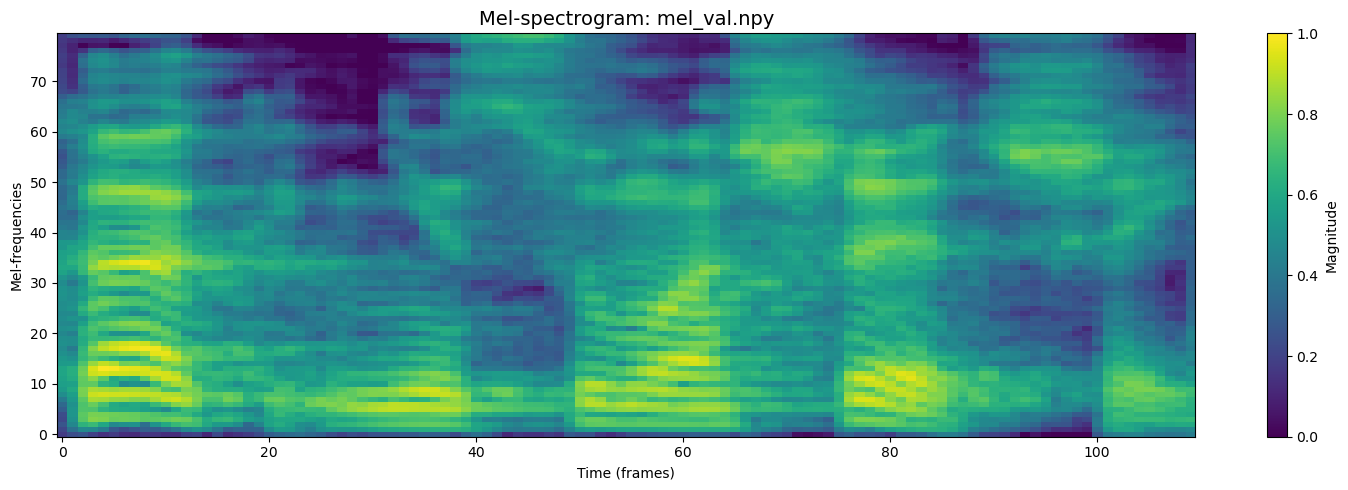

In [14]:
# Visualize mel-spectrogram
plt.figure(figsize=(15, 5))
# Transpose mel to have (frequencies, time) layout
plt.imshow(mel.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.title(f'Mel-spectrogram: {os.path.basename(mel_files[0])}', fontsize=14)
plt.xlabel('Time (frames)')
plt.ylabel('Mel-frequencies')
plt.tight_layout()
plt.show()

In [15]:
# Prepare mel-spectrogram for model
# mel is loaded as (time, mel_bins), need to transpose to (mel_bins, time)
# Add batch dimension and convert to torch tensor
mel_tensor = torch.FloatTensor(mel.T).unsqueeze(0)  # [1, mel_bins, time]

print(f"Mel-tensor shape: {mel_tensor.shape}")

# Generate audio with temperature 0.6 (cleaner generation)
print("\nGenerating audio...")
with torch.no_grad():
    audio = infer_with_temperature(upsample_net, waveglow, mel_tensor, temperature=0.6)

print(f"Generated audio shape: {audio.shape}")
print(f"Duration: {audio.shape[-1] / 22050:.2f} seconds")

Mel-tensor shape: torch.Size([1, 80, 110])

Generating audio...
Generated audio shape: torch.Size([1, 1, 28160])
Duration: 1.28 seconds


In [16]:
audio_np = audio[0, 0].numpy()
Audio(audio_np, rate=22050)

### Сравнение разных температур

Давайте сгенерируем аудио с разными температурами и сравним результаты.

In [17]:
# Generate audio with different temperatures
temperatures = [0.4, 0.6, 0.8, 1.0]
generated_audios = {}

print("Generating audio with different temperatures...")
with torch.no_grad():
    for temp in temperatures:
        audio = infer_with_temperature(upsample_net, waveglow, mel_tensor, temperature=temp)
        generated_audios[temp] = audio[0, 0].numpy()
        print(f"  Temperature {temp}: std = {audio.std().item():.4f}")

print("\nGeneration completed!")

Generating audio with different temperatures...
  Temperature 0.4: std = 0.0354
  Temperature 0.6: std = 0.0531
  Temperature 0.8: std = 0.0776
  Temperature 1.0: std = 0.1100

Generation completed!


In [18]:
print("Temperature = 0.4 (more deterministic):")
display(Audio(generated_audios[0.4], rate=22050))

print("\nTemperature = 0.6 (recommended):")
display(Audio(generated_audios[0.6], rate=22050))

print("\nTemperature = 0.8:")
display(Audio(generated_audios[0.8], rate=22050))

print("\nTemperature = 1.0 (standard):")
display(Audio(generated_audios[1.0], rate=22050))

Temperature = 0.4 (more deterministic):



Temperature = 0.6 (recommended):



Temperature = 0.8:



Temperature = 1.0 (standard):


In [19]:
# Generate audio from all mel-spectrograms
all_generated_audios = []

print("Generating audio from all mel-spectrograms")

with torch.no_grad():
    for idx, mel_file in enumerate(mel_files, 1):
        # Load mel-spectrogram
        mel = np.load(mel_file)
        mel_tensor = torch.FloatTensor(mel.T).unsqueeze(0)  # Transpose and add batch
        
        # Generate audio
        audio = infer_with_temperature(upsample_net, waveglow, mel_tensor, temperature=0.6)
        audio_np = audio[0, 0].numpy()
        
        all_generated_audios.append({
            'filename': os.path.basename(mel_file),
            'mel': mel,
            'audio': audio_np,
            'duration': len(audio_np) / 22050
        })
        
        print(f"{idx}. {os.path.basename(mel_file)}: "
              f"{mel.shape} -> {audio_np.shape} "
              f"({all_generated_audios[-1]['duration']:.2f} sec)")

print(f"\nTotal generated: {len(all_generated_audios)} audios")

Generating audio from all mel-spectrograms
1. mel_val.npy: (110, 80) -> (28160,) (1.28 sec)
2. mel_val2.npy: (99, 80) -> (25344,) (1.15 sec)
3. mel_val3.npy: (258, 80) -> (66048,) (3.00 sec)

Total generated: 3 audios


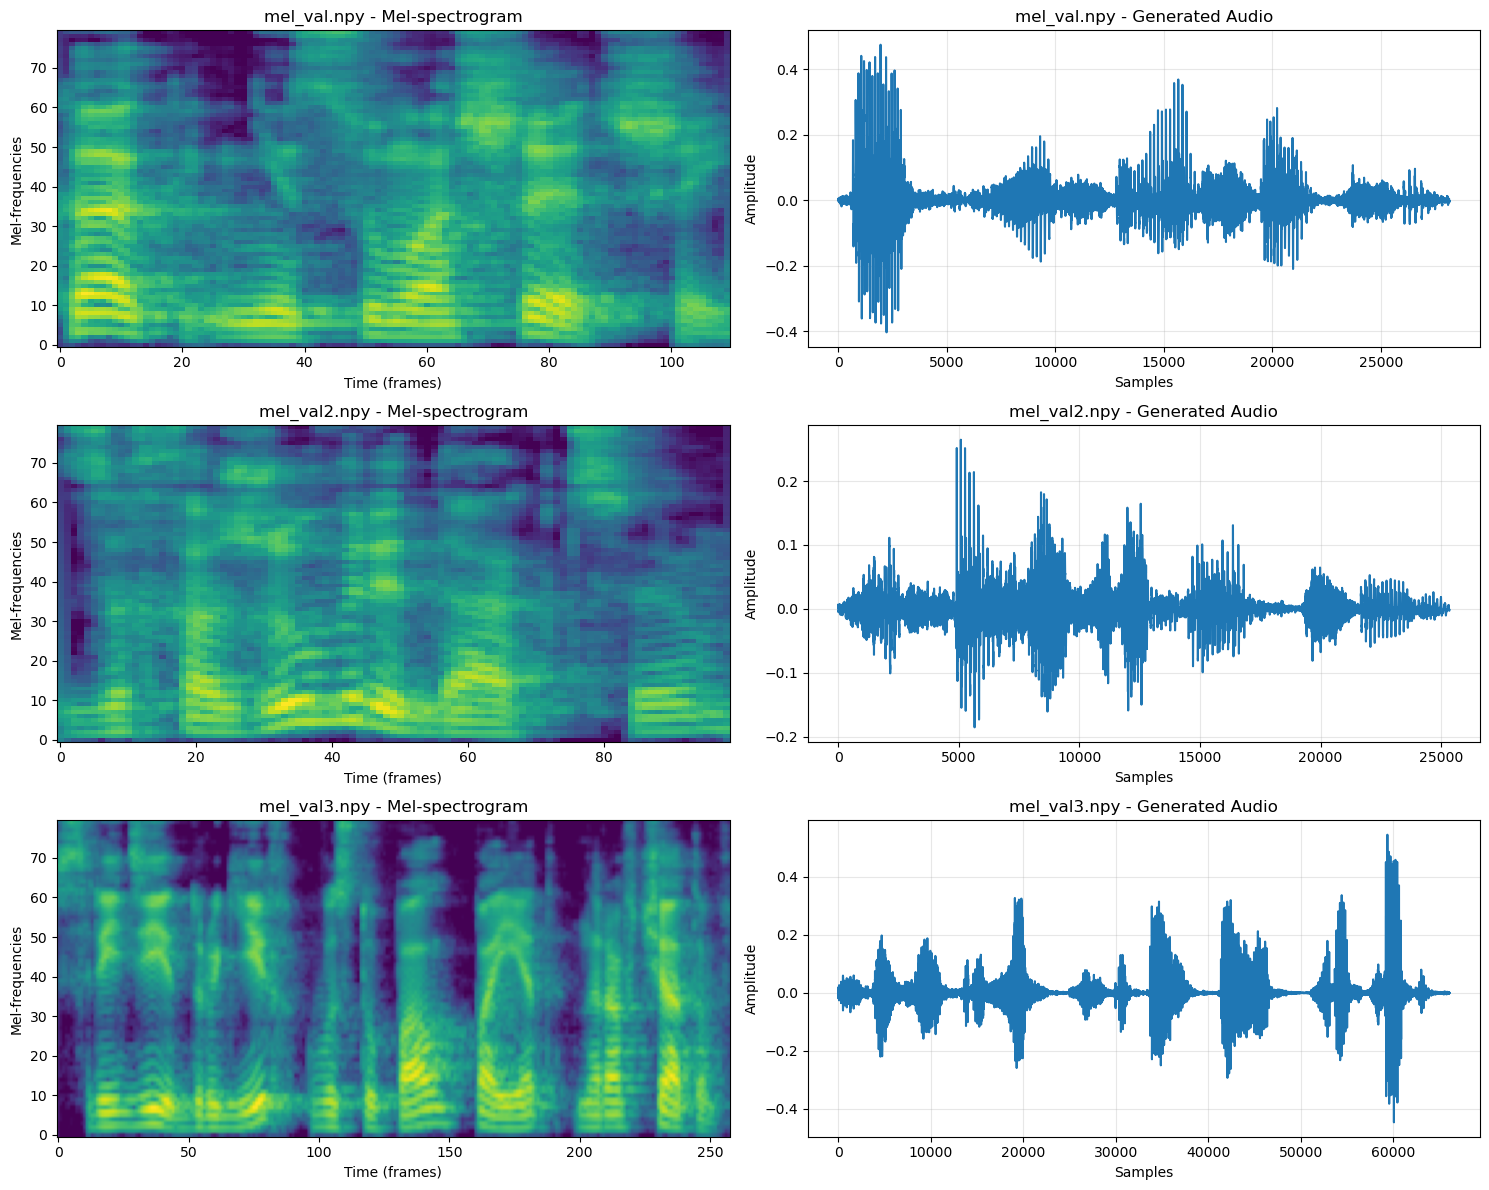

In [20]:
# Visualize all results
fig, axes = plt.subplots(len(all_generated_audios), 2, figsize=(15, 4 * len(all_generated_audios)))

if len(all_generated_audios) == 1:
    axes = axes.reshape(1, -1)

for idx, item in enumerate(all_generated_audios):
    # Mel-spectrogram (Transposed for correct visualization: Time on X, Freq on Y)
    axes[idx, 0].imshow(item['mel'].T, aspect='auto', origin='lower', cmap='viridis')
    axes[idx, 0].set_title(f"{item['filename']} - Mel-spectrogram", fontsize=12)
    axes[idx, 0].set_xlabel('Time (frames)')
    axes[idx, 0].set_ylabel('Mel-frequencies')
    
    # Waveform
    axes[idx, 1].plot(item['audio'])
    axes[idx, 1].set_title(f"{item['filename']} - Generated Audio", fontsize=12)
    axes[idx, 1].set_xlabel('Samples')
    axes[idx, 1].set_ylabel('Amplitude')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Прослушивание всех сгенерированных аудио

In [21]:
for item in all_generated_audios:
    print(f"{item['filename']} ({item['duration']:.2f} sec)")
    display(Audio(item['audio'], rate=22050))

mel_val.npy (1.28 sec)


mel_val2.npy (1.15 sec)


mel_val3.npy (3.00 sec)
